# Object Detection

## Part 1 - Importing the libraries

In [ ]:
!pip install ultralytics

In [ ]:
import os
import cv2
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from ultralytics.utils.downloads import download

## Part 2 - Downloading the Dataset

In [3]:
dataset_url = "https://ultralytics.com/assets/coco128.zip"
download(dataset_url)

Unzipping /content/coco128.zip to /content/coco128...: 100% ━━━━━━━━━━━━ 263/263 2.1Kfiles/s 0.1s


## Part 3 - Loading an Image

In [5]:
import os

for root, dirs, files in os.walk("coco128"):
    print(root)
    print(files[:3])
    break

coco128
['LICENSE', 'README.txt']


In [6]:
image_path = "coco128/images/train2017/000000000025.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

## Part 4 - Visualising the Image

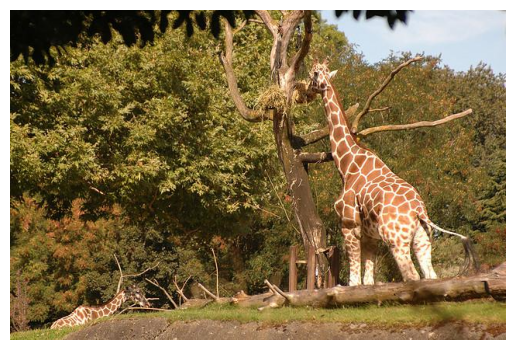

In [7]:
plt.imshow(image)
plt.axis("off")
plt.show()

## Part 5 - Loading YOLOv8

In [8]:
model = YOLO("yolov8n.pt")

## Part 6 - Performing Object Detection

In [9]:
results = model.predict(
    image,
    conf = 0.25,
    verbose = False
)

## Part 7 - Displaying the Detection Results

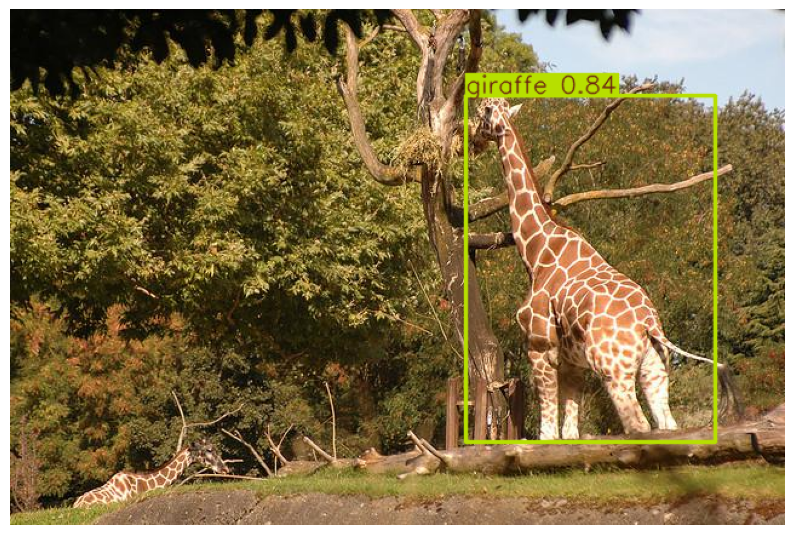

In [10]:
output = results[0].plot()
plt.figure(figsize = (10, 10))
plt.imshow(output)
plt.axis("off")
plt.show()

## Part 8 - Printing the Detected Objects

In [11]:
boxes = results[0].boxes

for box in boxes:

    class_id = int(box.cls)
    confidence = float(box.conf)

    print(model.names[class_id], confidence)

giraffe 0.8445845246315002


## Part 9 - Bounding Box Prediction

In [12]:
for box in boxes:

    x1, y1, x2, y2 = box.xyxy[0]
    print("Bounding Box:", int(x1), int(y1), int(x2), int(y2))

Bounding Box: 376 71 582 357


## Part 10 - Object Localization

In [13]:
for box in boxes:

    x1, y1, x2, y2 = box.xyxy[0]

    width = x2 - x1
    height = y2 - y1

    print("Width:", int(width), "Height:", int(height))

Width: 205 Height: 286


## Part 11 - Predicting Multiple Images

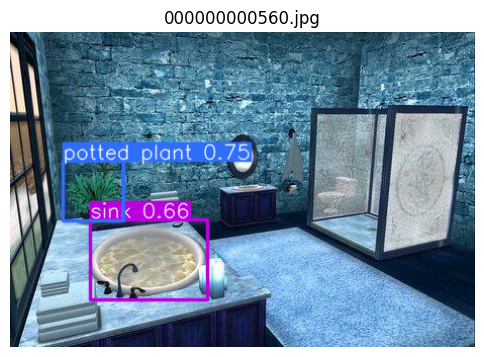

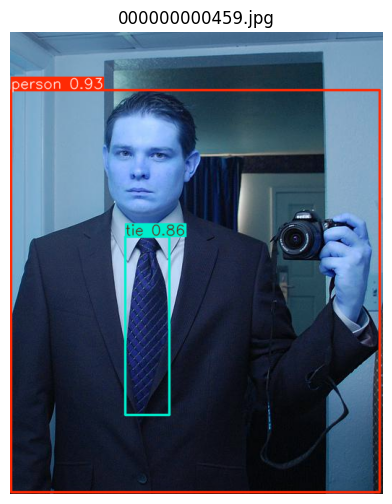

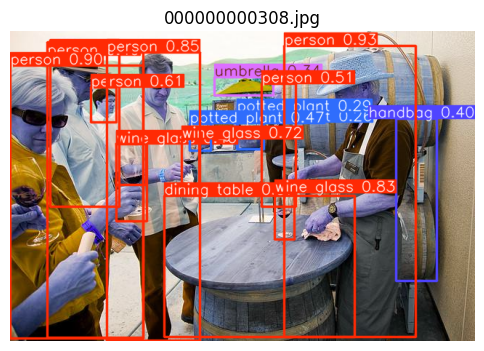

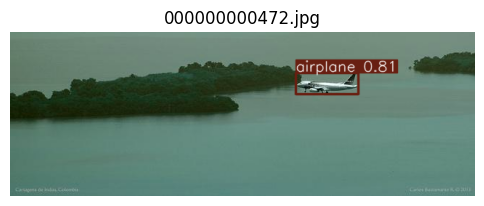

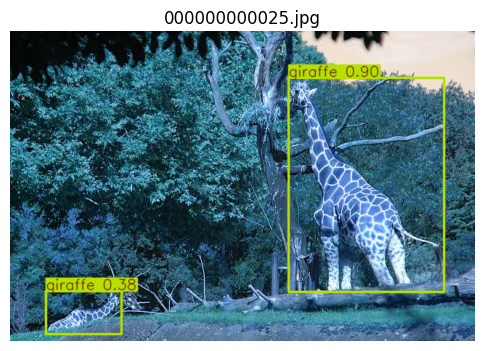

In [14]:
folder = "coco128/images/train2017"
images = os.listdir(folder)[:5]

for img in images:

    prediction = model.predict(
        os.path.join(folder, img),
        verbose = False
    )

    output = prediction[0].plot()

    plt.figure(figsize=(6, 6))
    plt.imshow(output)
    plt.title(img)
    plt.axis("off")
    plt.show()

## Part 12 - Predicting a Video

In [15]:
video_path = kagglehub.dataset_download("chicicecream/720p-road-and-traffic-video-for-object-detection")
print("Dataset location:", video_path)

100%|██████████| 137M/137M [00:00<00:00, 244MB/s]

Extracting files...


Dataset location: /root/.cache/kagglehub/datasets/chicicecream/720p-road-and-traffic-video-for-object-detection/versions/1


In [16]:
video_file = os.path.join(video_path, "4K Road traffic video for object detection and tracking - free download now.mp4")
print(video_file)

/root/.cache/kagglehub/datasets/chicicecream/720p-road-and-traffic-video-for-object-detection/versions/1/4K Road traffic video for object detection and tracking - free download now.mp4


In [17]:
results = model.predict(
    source = video_file,
    save = True,
    stream = True
)

for r in results:
    pass

print("Video prediction completed!")

Results saved to /content/runs/detect/predict
Video prediction completed!


## Part 13 - Predicting from Webcam

In [18]:
model.predict(
    source = 0,
    show = True
)

## Part 14 - Training YOLOv8 on a Custom Dataset

In [19]:
train_model = YOLO("yolov8n.pt")

In [ ]:
train_model.train(
    data = "coco128.yaml",
    epochs = 5,
    imgsz = 640,
    batch = 16
)

## Part 15 - Validating the Model

In [ ]:
metrics = train_model.val()

In [ ]:
print(metrics)

## Part 16 - Saving the Model

In [ ]:
train_model.export(format = "onnx")

## Part 17 - Making Predictions on New Images

In [26]:
results = train_model.predict(
    "image.jpg",
    save = True
)


image 1/1 /content/image.jpg: 480x640 3 chairs, 6.1ms
Speed: 1.6ms preprocess, 6.1ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict-2


## Part 18 - Comparing Object Detection Models

| Model        | One Stage / Two Stage | Speed          | Accuracy  |
| ------------ | --------------------- | -------------- | --------- |
| YOLOv3       | One Stage             | Fast           | High      |
| YOLOv5       | One Stage             | Very Fast      | Very High |
| **YOLOv8**   | One Stage             | Extremely Fast | Excellent |
| SSD          | One Stage             | Fast           | Moderate  |
| RetinaNet    | One Stage             | Medium         | Very High |
| Faster R-CNN | Two Stage             | Slow           | Excellent |
